# Global zone: 635 nm experiment and simulation

A separate, step-by-step notebook based on `global_zone.ipynb`. Each short code block has an explanation immediately above it. Run the cells from top to bottom with **Shift + Enter**.

The selected experimental source is `Global/635/Imported_frames.mat`, labeled **635 nm** in the original notebook and in the source file. The filename of this notebook retains the initial 650 nm study name; the experimental settings below record the selected 635 nm measurement.

This first step imports **only the image at 90 µm**, together with the small coordinate arrays needed to interpret it. The remaining images stay in the source file. The Lumerical section imports the supplied XY cut, normalizes its map to its own peak, and plots it in the same style. The final section compares axial and radial line cuts through y = 0 µm and x = −36.5 µm in two panels.

## Block 1 — Import the basic tools

`Path` handles file locations. `numpy` handles numerical arrays, such as coordinates and camera images. `h5py` reads the HDF5-based MATLAB v7.3 experimental files used by the original notebook. Importing these packages does **not** load a measurement.

The supplied Lumerical file is also HDF5-based, so its import below uses the same `h5py` reader.

In [34]:
from pathlib import Path  # Build and check file paths.
import numpy as np       # Work with numerical arrays.
import h5py              # Read the experimental MATLAB v7.3 file.

## Block 2 — Choose the source and image height

The experimental path and wavelength below are the settings you supplied. `REQUESTED_HEIGHT_UM = 90.0` selects the 90 µm image using the height coordinates saved in the MAT file, following the coordinate convention in `global_zone.ipynb`.

The import requires an actual 90 µm plane (allowing only a tiny numerical tolerance); it will stop if that plane is missing instead of substituting a different height. `LUMERICAL_MAT_PATH` points to the simulation file you supplied.

In [35]:
TARGET_WAVELENGTH_NM = 635  # Requested study wavelength.

# Experimental source selected for this notebook.
EXPERIMENT_WAVELENGTH_NM = 635
EXPERIMENT_MAT_PATH = '/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Experiments/Measurements/3-6-ba2-processed_re/Global/635/Imported_frames.mat'

# Import only this measured image plane (units: micrometres).
REQUESTED_HEIGHT_UM = 90.0

# Reserved for the simulation file that you will provide later.
LUMERICAL_MAT_PATH = '/Users/yiyangzhi/Downloads/XY_cut_96.mat'

## Block 3 — Check the experimental file location

Convert the supplied path to a `Path` object and check that it points to an HDF5-based MATLAB file. These checks do not load any camera images. The printed wavelength keeps the experimental label visible.

In [36]:
EXPERIMENT_MAT_PATH = Path(EXPERIMENT_MAT_PATH).expanduser()
if not EXPERIMENT_MAT_PATH.is_file():
    raise FileNotFoundError(EXPERIMENT_MAT_PATH)
if not h5py.is_hdf5(EXPERIMENT_MAT_PATH):
    raise ValueError("Expected the MATLAB v7.3 experimental file used by global_zone.ipynb.")
print(f"Experimental source ({EXPERIMENT_WAVELENGTH_NM:g} nm):")
print(EXPERIMENT_MAT_PATH)

Experimental source (635 nm):
/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Experiments/Measurements/3-6-ba2-processed_re/Global/635/Imported_frames.mat


## Block 4 — Read the coordinates, without loading the image stack

This MAT file stores a MATLAB class object, so its HDF5 arrays have internal reference names. The following mapping was checked against the reader and coordinate values in `global_zone.ipynb` for **this specific experimental file**:

| HDF5 dataset | Meaning here |
| --- | --- |
| `#refs#/v` | All saved height coordinates, in µm |
| `#refs#/q` | Image x coordinates, in µm (axial direction in the original notebook) |
| `#refs#/r` | Image y coordinates, in µm (radial direction in the original notebook) |
| `#refs#/p` | Stored normalized image stack, ordered as `(height, x, y)` |

`[:, 0]` converts each saved column vector into a one-dimensional coordinate array. Reading `.shape` returns the stack dimensions without loading the stack. The internal reference names are specific to this file; inspect the mapping again if you replace it with another MAT export.

Opening with `"r"` gives read-only access. Each `with` block closes the file automatically after its reads finish.

In [37]:
# These coordinate vectors are small; no image pixels are read in this block.
with h5py.File(EXPERIMENT_MAT_PATH, "r") as mat_file:
    experiment_heights_um = mat_file["#refs#/v"][:, 0]
    experiment_x_um = mat_file["#refs#/q"][:, 0]
    experiment_y_um = mat_file["#refs#/r"][:, 0]
    stored_stack_shape = mat_file["#refs#/p"].shape

## Block 5 — Find the 90 µm plane

First check that the stack dimensions agree with the coordinate lengths. Then find the height coordinate equal to 90 µm. `rtol=0` and `atol=1e-6` allow only a one-millionth-of-a-micrometre numerical tolerance.

Python counts indices from zero. In this file, **index 89 corresponds to 90 µm**; index 90 would select a different plane. The selected index is found from the saved coordinates rather than assumed.

In [38]:
expected_shape = (len(experiment_heights_um), len(experiment_x_um), len(experiment_y_um))
if stored_stack_shape != expected_shape:
    raise ValueError("The image stack and coordinate lengths do not agree.")

height_matches = np.flatnonzero(np.isclose(
    experiment_heights_um, REQUESTED_HEIGHT_UM, rtol=0, atol=1e-6
))
if len(height_matches) != 1:
    raise ValueError(f"Expected one measured plane at {REQUESTED_HEIGHT_UM:g} µm.")

experiment_height_index = int(height_matches[0])
experiment_height_um = float(experiment_heights_um[experiment_height_index])

## Block 6 — Import only that image

The integer `experiment_height_index` selects **one height** directly from the file. The two `:` entries retain every x and y pixel in that plane. There is no conversion of the full three-dimensional stack into a NumPy array.

The selected plane is stored as `(x, y)`. `.T` transposes it into the usual image order `(y, x)`, so `experiment_image[row, column]` corresponds to `experiment_y_um[row]` and `experiment_x_um[column]`. This matches the image orientation used by the original notebook.

`experiment_image` contains the source file's **stored normalized intensity** (`Znorm`), which is dimensionless. We preserve those values directly: there is no additional normalization to this image's peak, background subtraction, cropping, smoothing, or fitting.

In [39]:
# Read one 2D plane from disk, then put its axes in (y, x) order.
with h5py.File(EXPERIMENT_MAT_PATH, "r") as mat_file:
    experiment_image = mat_file["#refs#/p"][experiment_height_index, :, :].T

## Block 7 — Check the imported image

These checks catch a coordinate mismatch or unexpected intensity values before we use the image in a comparison. They inspect only the image already in memory. A peak below 1 is expected when the selected plane does not contain the maximum used for the stored normalization.

The imported data are ready as `experiment_image`, `experiment_x_um`, and `experiment_y_um`. `experiment_height_um` records the selected physical height; `EXPERIMENT_WAVELENGTH_NM` records the experimental wavelength. The summary below confirms the height, array size, and intensity range without making a plot.

In [40]:
if experiment_image.shape != (len(experiment_y_um), len(experiment_x_um)):
    raise ValueError("Image rows and columns do not match the y and x coordinates.")
if not np.isfinite(experiment_image).all():
    raise ValueError("The imported image contains NaN or infinite values.")
if experiment_image.min() < -1e-9 or experiment_image.max() > 1 + 1e-9:
    raise ValueError("The image is outside the expected stored normalization range.")

print(f"Loaded {EXPERIMENT_WAVELENGTH_NM:g} nm at {experiment_height_um:g} µm "
      f"(height index {experiment_height_index}).")
print(f"Image shape (y, x): {experiment_image.shape}; {experiment_image.nbytes / 1024**2:.1f} MiB")
print(f"Stored normalized intensity: {experiment_image.min():.6f} to {experiment_image.max():.6f}")

Loaded 635 nm at 90 µm (height index 89).
Image shape (y, x): (1024, 1280); 10.0 MiB
Stored normalized intensity: 0.000000 to 0.907258


## Block 8 — Choose the 635 nm display color

Use the same approximate 635 nm display color, `#ff3900`, as `global_zone.ipynb`. The colormap goes from **black at 0** to **red at 1**. This is a display convention for the intensity image, not a calibrated reproduction of a laser's perceived color.

The image already contains normalized intensity. We will keep those values and fix the colorbar at **0–1**, so this plane's peak of about 0.907 remains below 1.

In [41]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Increasing intensity appears as increasing brightness of the chosen red.
cmap_635 = LinearSegmentedColormap.from_list("635_nm", ["black", "#ff3900"])

## Block 9 — Display the 90 µm image

`pcolormesh` places the image pixels at their saved x and y coordinates. `shading="nearest"` centers each colored pixel on its coordinate without smoothing the intensity values. Equal axis scaling gives one micrometre the same displayed length horizontally and vertically.

Your plot below shifts the displayed experimental x coordinates by −19 µm and shows a 40 µm × 40 µm window centered at x = −36.5 µm, y = 0. These are display settings; the imported coordinates and image remain unchanged. It uses the image already in memory and does not load another height plane.

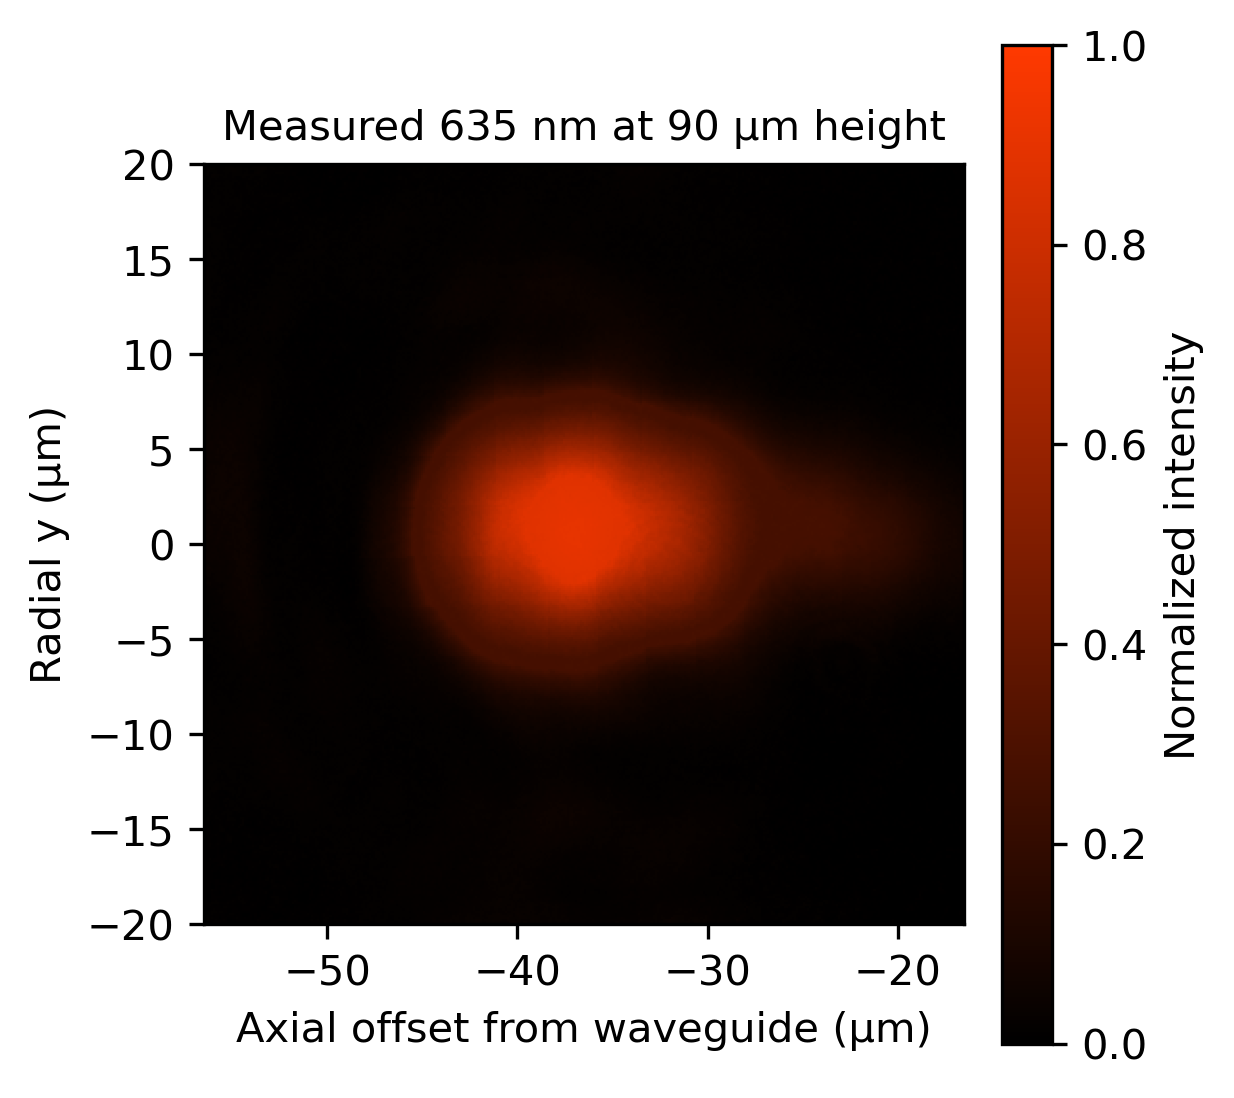

In [42]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=300, constrained_layout=True)
image_artist = ax.pcolormesh(
    experiment_x_um-19, experiment_y_um, experiment_image,
    shading="nearest", cmap=cmap_635, vmin=0, vmax=1,
)
ax.set_aspect("equal")  # Preserve the physical shape of the beam.
ax.set_ylim([-20,20]);
ax.set_xlim([-36.5-20,-36.5+20]);
ax.set(xlabel="Axial offset from waveguide (µm)", ylabel="Radial y (µm)")
ax.set_title('Measured 635 nm at 90 µm height', fontsize=10)
fig.colorbar(image_artist, ax=ax, label="Normalized intensity",
             ticks=np.linspace(0, 1, 6), shrink=0.85)
plt.show()

## Block 10 — Import the Lumerical XY cut

The supplied `XY_cut_96.mat` is an HDF5-based MAT file containing just `x`, `y`, and a real, nonnegative 201 × 201 array named `P`. We read this supplied map directly and treat `P` as the exported intensity/power map for this plot; its precise physical definition is not included in the file.

The coordinate conversion is **metres × 10⁶ = micrometres**, following [Lumerical's documented position units](https://optics.ansys.com/hc/en-us/articles/360034397034-Units-and-normalization-conventions-in-Lumerical-solvers). The resulting ranges are x = −56.5 to −16.5 µm and y = −20 to 20 µm, matching your experimental display window. We use these simulation coordinates directly, without the experiment's −19 µm display shift.

**Axis convention:** a standard Lumerical `P(x, y)` MAT export is exposed by `h5py` in `(y, x)` order, which is already the order needed for plotting. We therefore keep the stored array order. This follows the [Lumerical image convention](https://optics.ansys.com/hc/en-us/articles/360034404014-Creating-2D-image-plots-with-MATLAB) and [MATLAB-compatible HDF5 dimension ordering](https://hdf5storage.readthedocs.io/en/latest/storage_format.html). Because this map is square, its shape alone cannot establish orientation; this assumes the export did not include a manual transpose.

The file has no wavelength or height variable. The simulation plot below uses your supplied title, “Simulated 635 nm at 90 µm height”; those values are not read from the MAT file metadata.

In [43]:
LUMERICAL_MAT_PATH = Path(LUMERICAL_MAT_PATH).expanduser()
if not LUMERICAL_MAT_PATH.is_file():
    raise FileNotFoundError(LUMERICAL_MAT_PATH)

with h5py.File(LUMERICAL_MAT_PATH, "r") as mat_file:
    simulation_x_um = mat_file["x"][...].ravel() * 1e6  # metres → µm
    simulation_y_um = mat_file["y"][...].ravel() * 1e6
    simulation_P = mat_file["P"][...]  # Keep the supplied map unchanged.

print(f"Loaded {LUMERICAL_MAT_PATH.name}: map shape {simulation_P.shape}")

Loaded XY_cut_96.mat: map shape (201, 201)


## Block 11 — Normalize the simulation intensity

Use **`simulation_image = simulation_P / simulation_P.max()`**. This divides every pixel by the peak over the entire supplied XY cut, so its brightest pixel is exactly 1. The original values remain available in `simulation_P`, and `simulation_peak` records the divisor.

We normalize the supplied `P` directly, without squaring it or subtracting its minimum. The checks below stop if its dimensions, values, or peak are unsuitable for this operation.

The simulation is normalized to **this cut's peak**. The experimental plot still uses its original stored normalization, whose 90 µm peak is about 0.907. Both colorbars span 0–1, but their absolute intensities are not calibrated against one another.

In [44]:
if simulation_P.shape != (len(simulation_y_um), len(simulation_x_um)):
    raise ValueError("The simulation map does not match the expected (y, x) shape.")
if np.iscomplexobj(simulation_P) or not np.isfinite(simulation_P).all():
    raise ValueError("Expected a finite, real intensity/power map in P.")
if np.any(simulation_P < 0):
    raise ValueError("P contains negative values; check the exported quantity.")

simulation_peak = float(simulation_P.max())
if simulation_peak <= 0:
    raise ValueError("Cannot normalize a map with no positive intensity.")
simulation_image = simulation_P / simulation_peak
print(f"Normalization divisor: {simulation_peak:.8g}; normalized peak: {simulation_image.max():.1f}")

Normalization divisor: 0.0083998917; normalized peak: 1.0


## Block 12 — Plot the simulation in the same style

Reuse `cmap_635` and the experimental figure's size, resolution, axis labels, and viewing limits. The colorbar is fixed at **0–1**, with the same tick spacing and size. As above, equal axis scaling preserves the physical shape of the spot and `shading="nearest"` displays the sampled values without smoothing.

Run the experimental plotting block first: `fig` and `ax` refer to that figure. The separate names `simulation_fig` and `simulation_ax` keep both plots available.

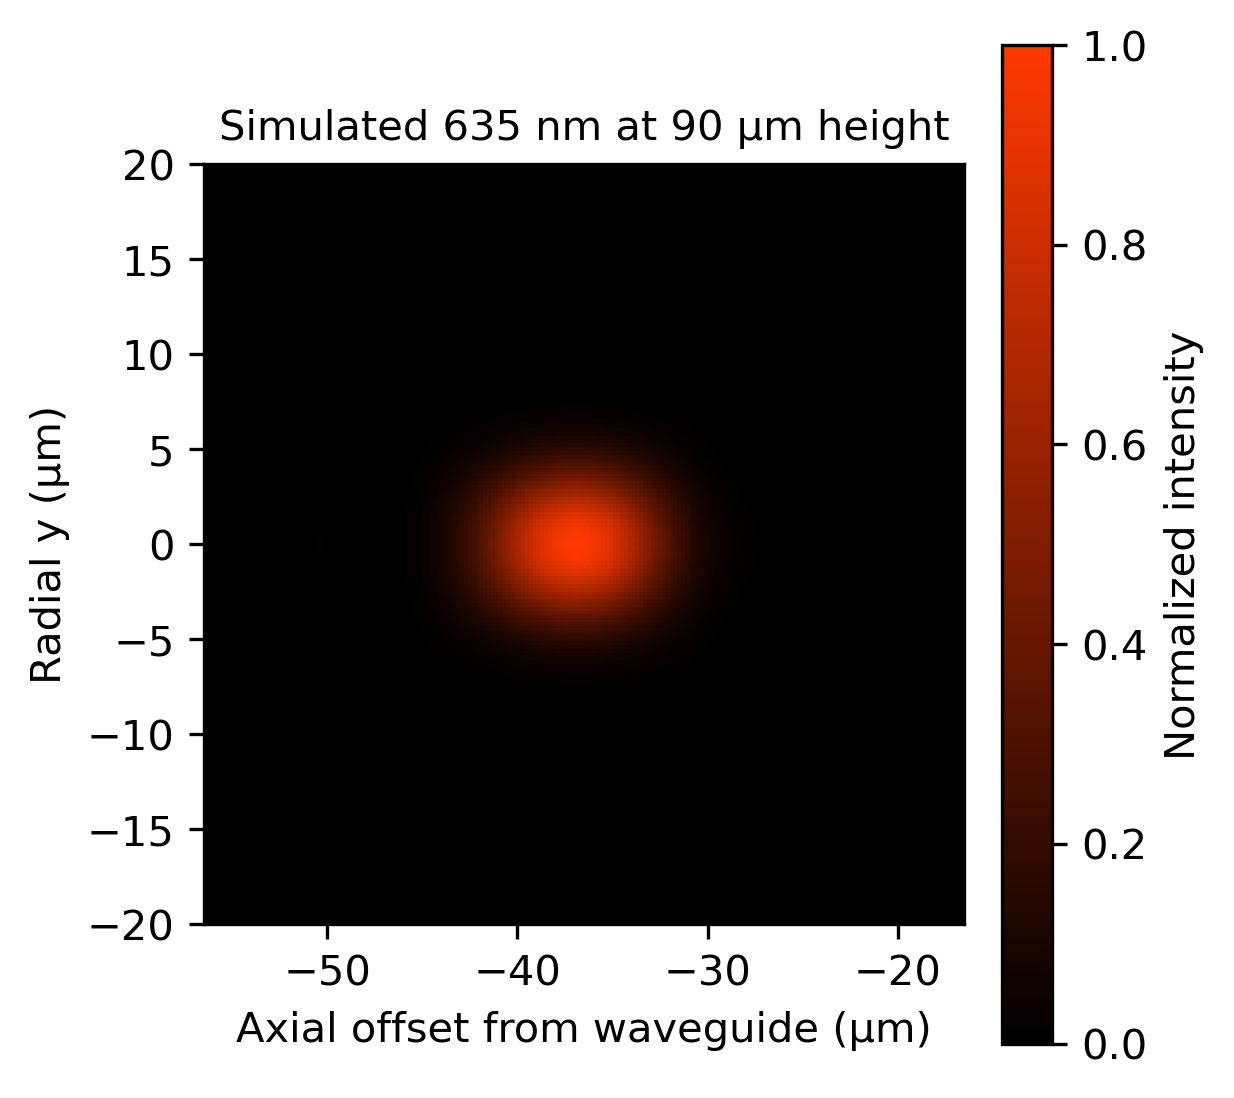

In [45]:
simulation_fig, simulation_ax = plt.subplots(
    figsize=fig.get_size_inches(), dpi=fig.dpi, constrained_layout=True)
simulation_artist = simulation_ax.pcolormesh(
    simulation_x_um, simulation_y_um, simulation_image,
    shading="nearest", cmap=cmap_635, vmin=0, vmax=1,
)
simulation_ax.set_aspect("equal")
simulation_ax.set(xlim=ax.get_xlim(), ylim=ax.get_ylim(),
                  xlabel=ax.get_xlabel(), ylabel=ax.get_ylabel())
simulation_ax.set_title('Simulated 635 nm at 90 µm height', fontsize=10)
simulation_fig.colorbar(simulation_artist, ax=simulation_ax,
                        label="Normalized intensity", ticks=np.linspace(0, 1, 6), shrink=0.85)
plt.show()

## Block 13 — Set the two cut positions

The **axial cut** varies x while holding **y = 0 µm**. The **radial cut** varies y while holding **x = −36.5 µm**. These positions refer to the coordinate system in your image plots.

For the experiment, use `experiment_x_um - 19`, exactly as in Block 9. Thus x = −36.5 µm in the plot corresponds to x = −17.5 µm in the original experimental coordinate array. The simulation already uses the plotted coordinate system, so its x coordinates are used directly.

This step only creates a coordinate array for the comparison and records the requested cut positions. It does not move or modify either image.

In [46]:
CUT_Y_UM = 0.0     # Fixed y for the axial (x) cut.
CUT_X_UM = -36.5   # Fixed x for the radial (y) cut, relative to the waveguide.

# Apply the same experimental coordinate offset used in the image plot.
experiment_plot_x_um = experiment_x_um - 19.0

## Block 14 — Extract both cuts at the requested coordinates

The experimental grid does not contain either requested position exactly. Linear interpolation blends the **two neighboring rows or columns** to evaluate the image at the requested position. This puts the experiment and simulation cuts at the same coordinates, instead of choosing slightly different nearest pixels.

Both images have `(y, x)` array order. `axis=0` interpolates between rows to give an axial profile at fixed y; `axis=1` interpolates between columns to give a radial profile at fixed x. `bounds_error=True` stops if a requested position is outside an image. Along each line, the original sample coordinates are retained.

The profiles keep the intensities from the displayed images: the experiment retains its stored normalization and the simulation retains `P / P.max()`. Each line is **not** independently rescaled to a peak of 1. These are profile comparisons, not an absolute optical-power calibration.

In [47]:
from scipy.interpolate import interp1d

# Axial profiles: one intensity value for each original x coordinate.
experiment_axial_cut = interp1d(
    experiment_y_um, experiment_image, axis=0, bounds_error=True)(CUT_Y_UM)
simulation_axial_cut = interp1d(
    simulation_y_um, simulation_image, axis=0, bounds_error=True)(CUT_Y_UM)

# Radial profiles: one intensity value for each original y coordinate.
experiment_radial_cut = interp1d(
    experiment_plot_x_um, experiment_image, axis=1, bounds_error=True)(CUT_X_UM)
simulation_radial_cut = interp1d(
    simulation_x_um, simulation_image, axis=1, bounds_error=True)(CUT_X_UM)

## Block 15 — Compare the axial and radial profiles

The left panel shows the **axial cut at y = 0 µm**; the right shows the **radial cut at x = −36.5 µm**. Red solid lines denote the experiment and dark dashed lines denote the Lumerical simulation.

The panels use the same coordinate windows as the image plots and share a normalized-intensity scale. The short line segments join the original samples along each cut; no fit, background subtraction, or additional smoothing is applied.

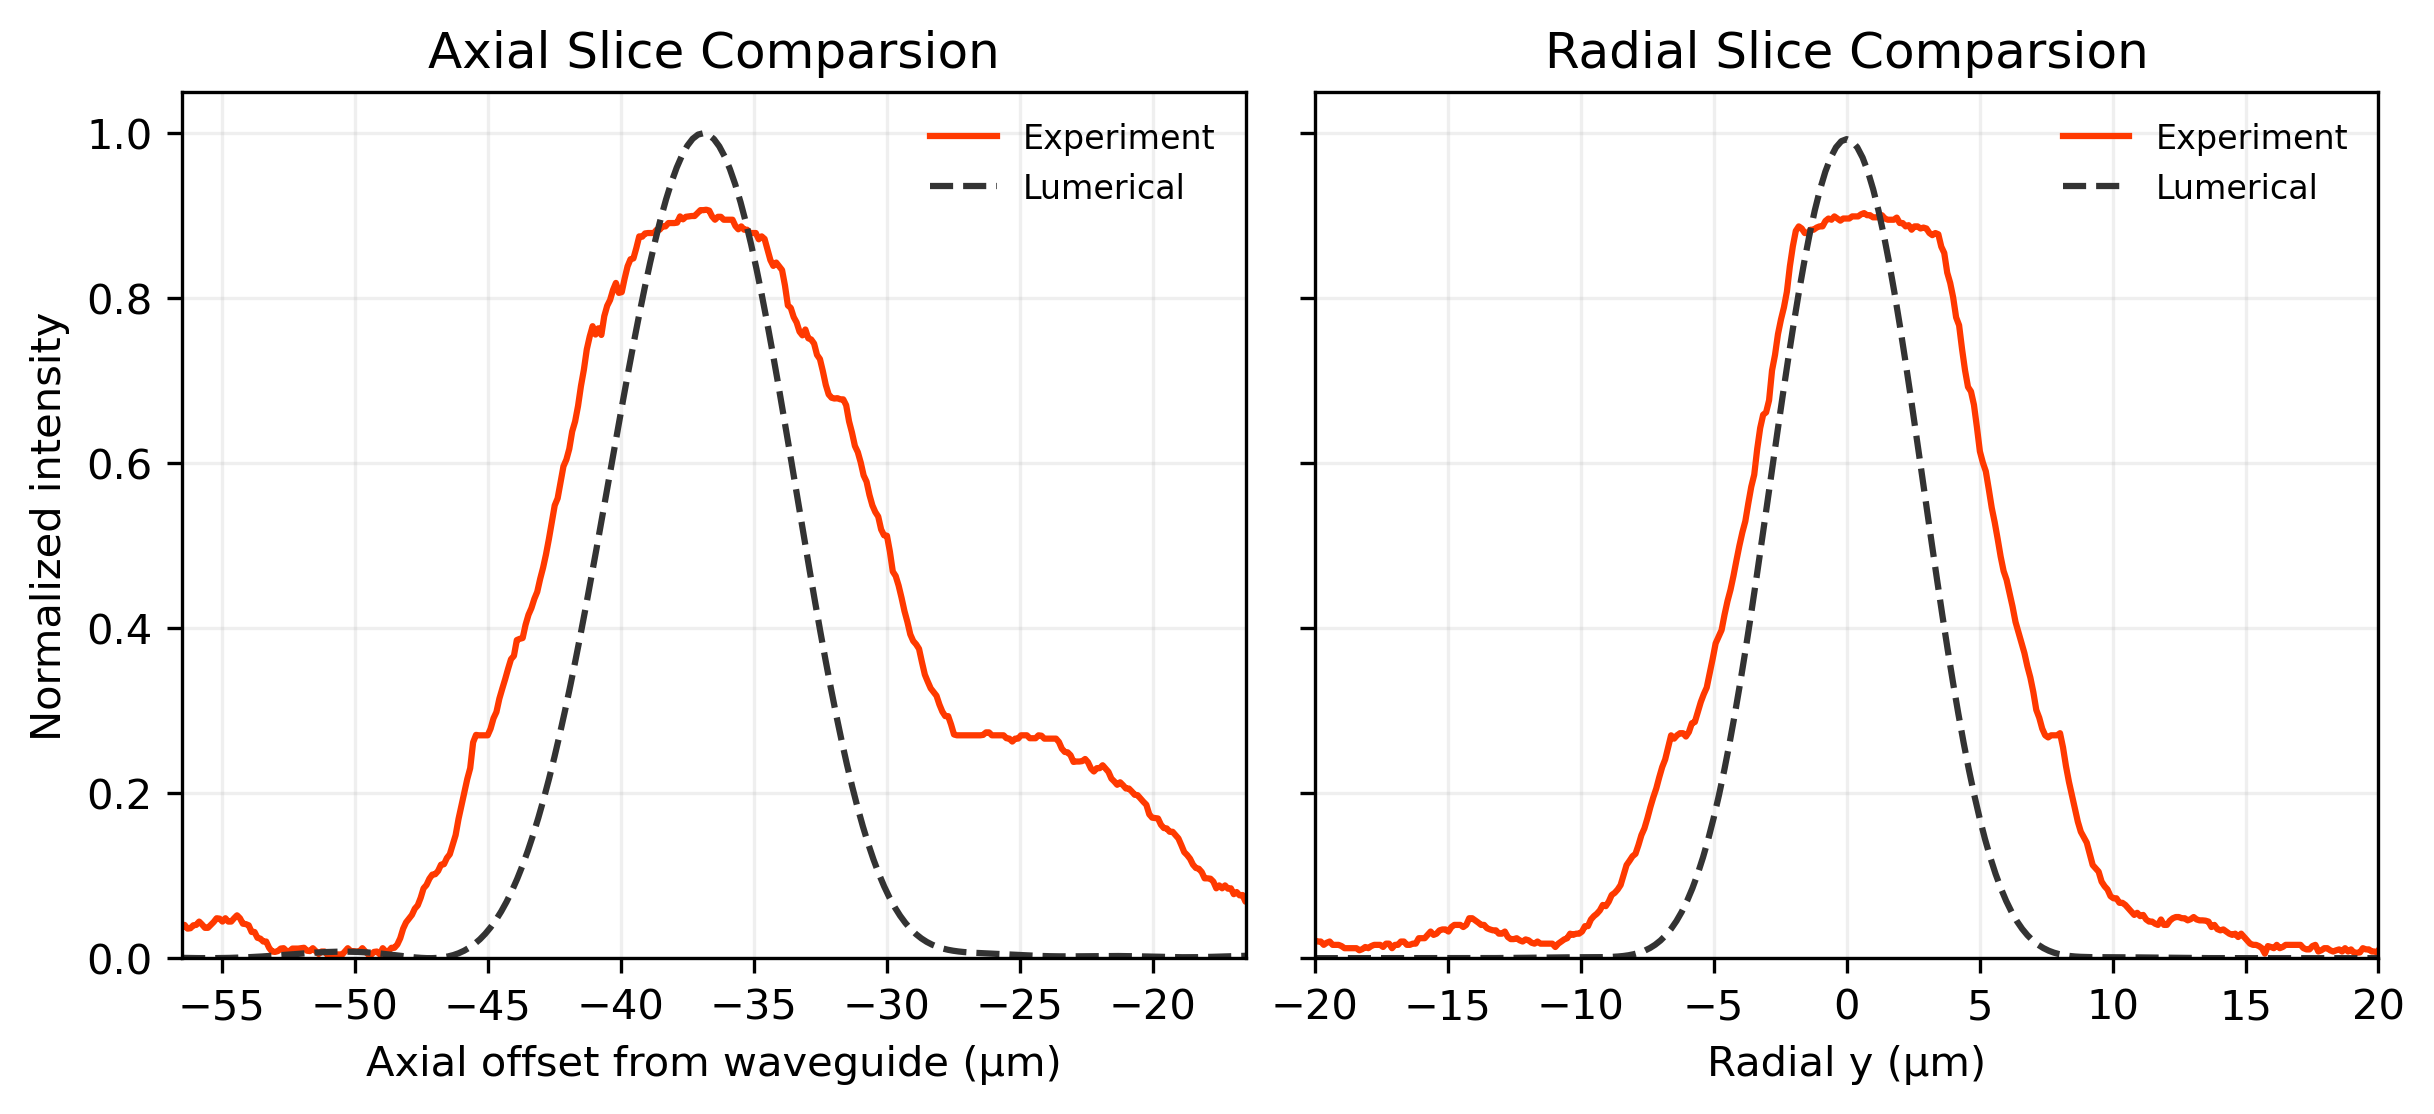

In [48]:
comparison_fig, (axial_ax, radial_ax) = plt.subplots(
    1, 2, figsize=(8, 3.6), dpi=fig.dpi, sharey=True, constrained_layout=True)
axial_ax.plot(experiment_plot_x_um, experiment_axial_cut, color="#ff3900", label="Experiment")
axial_ax.plot(simulation_x_um, simulation_axial_cut, color="0.2", ls="--", label="Lumerical")
radial_ax.plot(experiment_y_um, experiment_radial_cut, color="#ff3900", label="Experiment")
radial_ax.plot(simulation_y_um, simulation_radial_cut, color="0.2", ls="--", label="Lumerical")

axial_ax.set(title=f"Axial Slice Comparsion",
             xlabel=ax.get_xlabel(), xlim=ax.get_xlim(), ylabel="Normalized intensity")
radial_ax.set(title=f"Radial Slice Comparsion",
              xlabel=ax.get_ylabel(), xlim=ax.get_ylim())
for cut_ax in (axial_ax, radial_ax):
    cut_ax.set_ylim(0, 1.05)
    cut_ax.grid(alpha=0.2)
    cut_ax.legend(frameon=False, fontsize=8)
plt.show()